### Random Forest Classifier

In [64]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,r2_score,mean_squared_error
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', None)

In [41]:
data = pd.read_csv("./dataset/finance.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       100 non-null    int64  
 1   Firm_Name                  100 non-null    object 
 2   Total_Audit_Engagements    100 non-null    int64  
 3   High_Risk_Cases            100 non-null    int64  
 4   Compliance_Violations      100 non-null    int64  
 5   Fraud_Cases_Detected       100 non-null    int64  
 6   Industry_Affected          100 non-null    object 
 7   Total_Revenue_Impact       100 non-null    float64
 8   AI_Used_for_Auditing       100 non-null    object 
 9   Employee_Workload          100 non-null    int64  
 10  Audit_Effectiveness_Score  100 non-null    float64
 11  Client_Satisfaction_Score  100 non-null    float64
dtypes: float64(3), int64(6), object(3)
memory usage: 9.5+ KB


In [19]:
data.head()

,Year,Firm_Name,Total_Audit_Engagements,High_Risk_Cases,Compliance_Violations,Fraud_Cases_Detected,Industry_Affected,Total_Revenue_Impact,AI_Used_for_Auditing,Employee_Workload,Audit_Effectiveness_Score,Client_Satisfaction_Score
0,2020,PwC,2829,51,123,39,1,114.24,No,57,5.8,8.4
1,2022,Deloitte,3589,185,30,60,1,156.98,Yes,58,5.3,6.7
2,2020,PwC,2438,212,124,97,1,131.83,No,76,6.1,6.2
3,2021,PwC,2646,397,55,97,1,229.11,No,60,5.1,8.6
4,2020,PwC,2680,216,99,46,1,48.00,No,51,9.1,6.7


In [10]:
data["Industry_Affected"].unique()

array(['PwC', 'Deloitte', 'Ernst & Young', 'KPMG'], dtype=object)

In [18]:
le = LabelEncoder()
data["Industry_Affected"] = le.fit_transform(data["Industry_Affected"])

<Axes: >

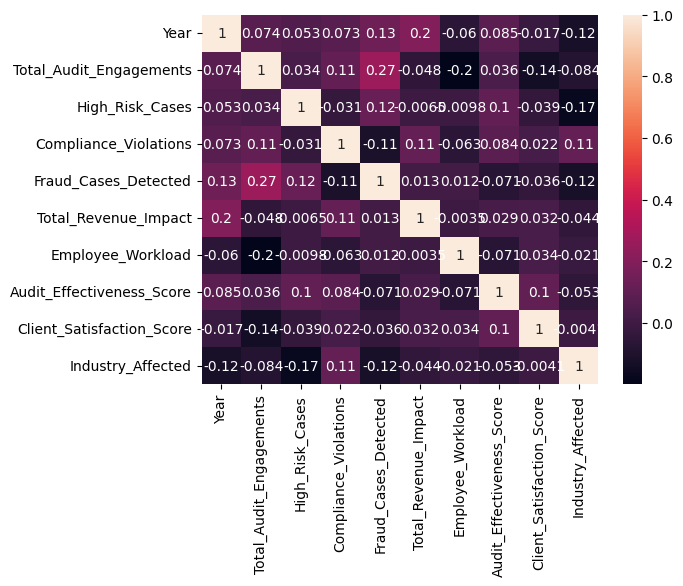

In [22]:
correlated = data[["Year","Total_Audit_Engagements","High_Risk_Cases","Compliance_Violations","Fraud_Cases_Detected","Total_Revenue_Impact","Employee_Workload","Audit_Effectiveness_Score","Client_Satisfaction_Score","Industry_Affected"]].corr(numeric_only = True)
sns.heatmap(data = correlated,annot = True)

In [33]:
poly = PolynomialFeatures(degree = 3,interaction_only=True,include_bias = False)
x_new = poly.fit_transform(data[["Year","Total_Audit_Engagements","High_Risk_Cases","Compliance_Violations","Fraud_Cases_Detected","Total_Revenue_Impact","Employee_Workload","Audit_Effectiveness_Score","Client_Satisfaction_Score","Industry_Affected"]])

In [34]:
x_new_df = pd.DataFrame(x_new, columns=poly.get_feature_names_out(features))

In [35]:
x_new_df.corr()

,Year,Total_Audit_Engagements,High_Risk_Cases,Compliance_Violations,Fraud_Cases_Detected,Total_Revenue_Impact,Employee_Workload,Audit_Effectiveness_Score,Client_Satisfaction_Score,Industry_Affected,...,Total_Revenue_Impact Employee_Workload Audit_Effectiveness_Score,Total_Revenue_Impact Employee_Workload Client_Satisfaction_Score,Total_Revenue_Impact Employee_Workload Industry_Affected,Total_Revenue_Impact Audit_Effectiveness_Score Client_Satisfaction_Score,Total_Revenue_Impact Audit_Effectiveness_Score Industry_Affected,Total_Revenue_Impact Client_Satisfaction_Score Industry_Affected,Employee_Workload Audit_Effectiveness_Score Client_Satisfaction_Score,Employee_Workload Audit_Effectiveness_Score Industry_Affected,Employee_Workload Client_Satisfaction_Score Industry_Affected,Audit_Effectiveness_Score Client_Satisfaction_Score Industry_Affected
Year,1.000000,0.074125,0.053115,0.072821,0.133996,0.197986,-0.060485,0.085397,-0.016865,-0.122274,...,0.224740,0.193911,0.063739,0.204882,0.087737,0.092955,0.025452,-0.090227,-0.099163,-0.076444
Total_Audit_Engagements,0.074125,1.000000,0.034309,0.106111,0.267385,-0.047823,-0.199313,0.035934,-0.142463,-0.084470,...,-0.088651,-0.186762,-0.164890,-0.054660,-0.103203,-0.134462,-0.128502,-0.130223,-0.139194,-0.085810
High_Risk_Cases,0.053115,0.034309,1.000000,-0.030904,0.122829,-0.006465,-0.009775,0.104043,-0.039145,-0.171923,...,-0.001690,-0.021271,-0.142540,0.018498,-0.140530,-0.169652,0.071147,-0.080149,-0.101792,-0.130049
Compliance_Violations,0.072821,0.106111,-0.030904,1.000000,-0.114610,0.112914,-0.062901,0.084088,0.022495,0.111795,...,0.099676,0.071082,0.236741,0.104458,0.244486,0.255569,0.047688,0.102507,0.133959,0.146237
Fraud_Cases_Detected,0.133996,0.267385,0.122829,-0.114610,1.000000,0.012651,0.012033,-0.070547,-0.035708,-0.120662,...,0.002380,0.007543,-0.121171,-0.014623,-0.156571,-0.138474,-0.027391,-0.111013,-0.092125,-0.116428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Total_Revenue_Impact Client_Satisfaction_Score Industry_Affected,0.092955,-0.134462,-0.169652,0.255569,-0.138474,0.518373,-0.041703,-0.014373,0.199852,0.691072,...,0.424988,0.492280,0.932646,0.477993,0.944990,1.000000,0.073758,0.617899,0.678821,0.692234
Employee_Workload Audit_Effectiveness_Score Client_Satisfaction_Score,0.025452,-0.128502,0.071147,0.047688,-0.027391,0.044696,0.498072,0.605445,0.626229,-0.045809,...,0.390458,0.377032,0.012306,0.441609,0.069504,0.073758,1.000000,0.238428,0.250820,0.283236
Employee_Workload Audit_Effectiveness_Score Industry_Affected,-0.090227,-0.130223,-0.080149,0.102507,-0.111013,-0.064373,0.211022,0.181842,0.027243,0.902818,...,0.032931,-0.012152,0.677414,-0.011249,0.679120,0.617899,0.238428,1.000000,0.906936,0.898911
Employee_Workload Client_Satisfaction_Score Industry_Affected,-0.099163,-0.139194,-0.101792,0.133959,-0.092125,-0.054446,0.230018,-0.036293,0.265673,0.893426,...,-0.021818,0.067716,0.678643,-0.007580,0.615162,0.678821,0.250820,0.906936,1.000000,0.897559


In [27]:
features = ["Year", "Total_Audit_Engagements", "High_Risk_Cases", "Compliance_Violations",
            "Fraud_Cases_Detected", "Total_Revenue_Impact", "Employee_Workload",
            "Audit_Effectiveness_Score", "Client_Satisfaction_Score"]

In [40]:
x = data[features]

In [42]:
y = data[ "Industry_Affected"]

In [43]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

In [53]:
model = RandomForestClassifier(n_estimators = 100)
model.fit(x_train,y_train)

RandomForestClassifier()

In [54]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

accuracy_score_train = accuracy_score(y_train,y_pred_train)
accuracy_score_test = accuracy_score(y_test,y_pred_test)

In [55]:
accuracy_score_train*100

100.0

In [56]:
accuracy_score_test*100

100.0

### Random Forest Regressor

In [57]:
data = pd.read_csv("./dataset/tesla.csv")

In [81]:
data.tail()

,Date,Close,High,Low,Open,Volume
3760,2025-06-10,326.089996,327.829987,310.670013,314.940002,151256500
3761,2025-06-11,326.429993,335.500000,322.500000,334.399994,122611400
3762,2025-06-12,319.109985,332.559998,316.859985,323.079987,105127500
3763,2025-06-13,325.309998,332.989990,313.299988,313.970001,128964300
3764,2025-06-16,329.130005,332.049988,326.410004,331.290009,82965200


In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3765 entries, 0 to 3764
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3765 non-null   datetime64[ns]
 1   Close   3765 non-null   float64       
 2   High    3765 non-null   float64       
 3   Low     3765 non-null   float64       
 4   Open    3765 non-null   float64       
 5   Volume  3765 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 176.6 KB


In [60]:
data["Date"] = pd.to_datetime(data["Date"])

<Axes: >

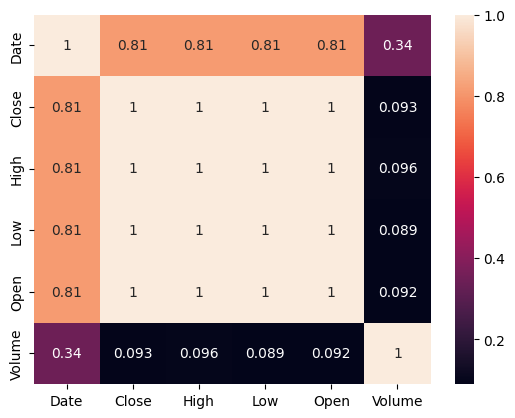

In [63]:
sns.heatmap(data = data.corr(),annot = True)

In [67]:
x = data[["Open","Volume"]]
y = data[["Close","High","Low"]]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

In [77]:
model = RandomForestRegressor()
model.fit(x_train,y_train)

RandomForestRegressor()

In [78]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

r2_score_train = r2_score(y_train,y_pred_train)
r2_score_test = r2_score(y_test,y_pred_test)

In [79]:
r2_score_train*100

99.98260103714367

In [80]:
r2_score_test*100

99.85265407471081

In [84]:
val = [313.970001,128964300]
res = model.predict([val])

C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [85]:
res

array([[316.06613068, 327.56649445, 305.93699432]])

In [88]:
mse = mean_squared_error(y_test,y_pred_test)
mse

18.857732615564604